Exercise 1:
-

1) Read file csv

In [2]:
import pandas as pd

# Đọc file
df = pd.read_csv("Lab1_Ex1_bank.csv",sep=";")

# Xem 5 dòng đầu
print(df.head())

# Kiểm tra cấu trúc dữ liệu
print(df.info())

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #  

2) Draw histogram for age

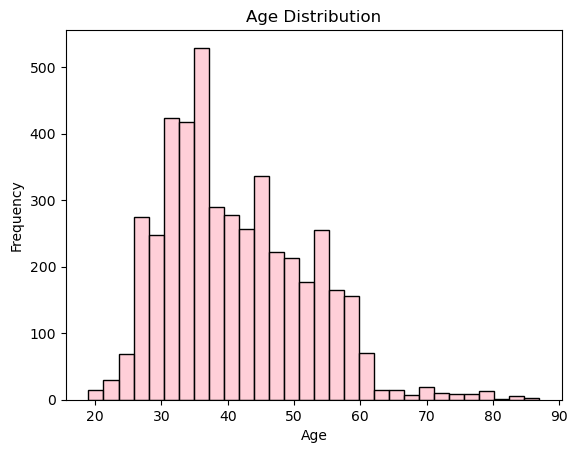

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df["age"], bins=30, color='pink')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

3) Draw a histogram for balance

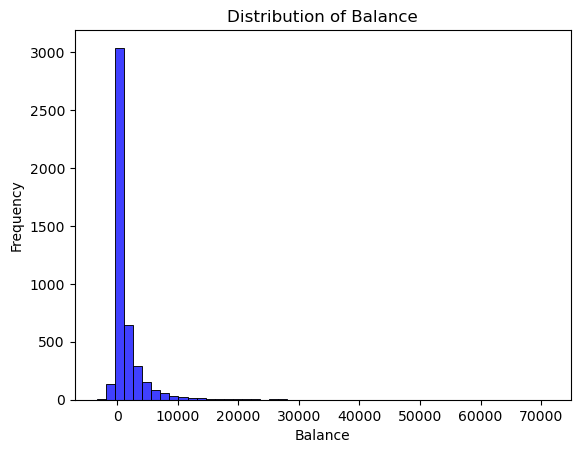

In [4]:
plt.figure()
sns.histplot(df["balance"], bins=50, color='blue')
plt.title("Distribution of Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

Boxplot of Balance

{'whiskers': [<matplotlib.lines.Line2D at 0x1a56ac76fd0>,
 'caps': [<matplotlib.lines.Line2D at 0x1a56ac77250>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a56ac76e90>],
 'medians': [<matplotlib.lines.Line2D at 0x1a56ac774d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a56ac77610>],
 'means': []}

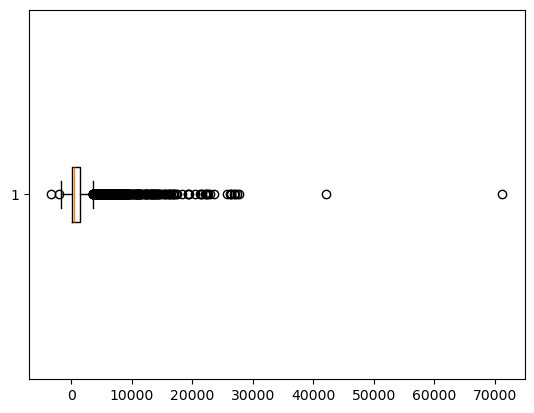

In [5]:
plt.boxplot(df["balance"], vert=False)

There are many outliers in Balance due to the box plot shows many points outside the UF and LF.

3) Draw a bar chart for job

In [6]:
job_counts = df["job"].value_counts()
print(job_counts)

job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64


job
management       0.214333
blue-collar      0.209246
technician       0.169874
admin.           0.105729
services         0.092236
retired          0.050874
self-employed    0.040478
entrepreneur     0.037160
unemployed       0.028312
housemaid        0.024773
student          0.018580
unknown          0.008405
Name: proportion, dtype: float64

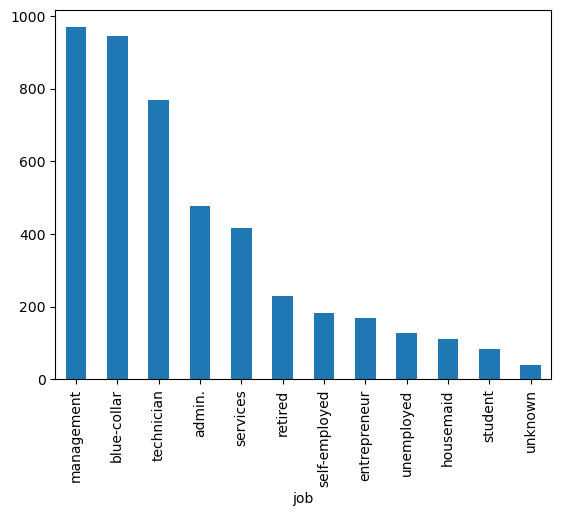

In [7]:
df['job'].value_counts().plot(kind='bar')
df['job'].value_counts(normalize=True)

The occupation has the highest proportion is Management.

4) Draw a scatter plot between balance and age.

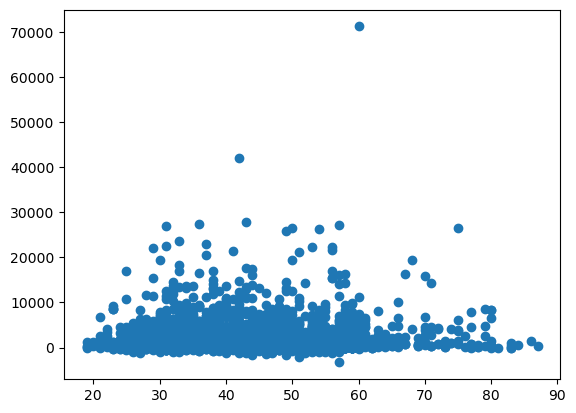

In [8]:
plt.scatter(df['age'], df['balance'])

Correlation between balance and age:

In [9]:
correlation = df[['age','balance']].corr()
print(correlation)

             age  balance
age      1.00000  0.08382
balance  0.08382  1.00000


The correlation coefficient is close to 0, means that there's almost no linear correlation between balance and age.

5) Draw a heatmap of the correlation matrix among numerical attributes.

               age   balance       day  duration  campaign     pdays  previous
age       1.000000  0.083820 -0.017853 -0.002367 -0.005148 -0.008894 -0.003511
balance   0.083820  1.000000 -0.008677 -0.015950 -0.009976  0.009437  0.026196
day      -0.017853 -0.008677  1.000000 -0.024629  0.160706 -0.094352 -0.059114
duration -0.002367 -0.015950 -0.024629  1.000000 -0.068382  0.010380  0.018080
campaign -0.005148 -0.009976  0.160706 -0.068382  1.000000 -0.093137 -0.067833
pdays    -0.008894  0.009437 -0.094352  0.010380 -0.093137  1.000000  0.577562
previous -0.003511  0.026196 -0.059114  0.018080 -0.067833  0.577562  1.000000


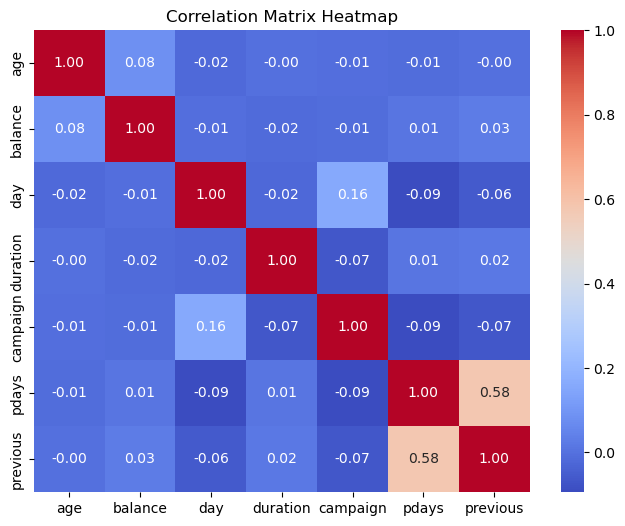

In [10]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,      # show values of correlation
    cmap="coolwarm",  
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")
plt.show()

6) How does the number of contacts (campaign) affect the outcome y?

In [11]:
pd.crosstab(df['campaign'], df['y'], normalize='index')

y,no,yes
campaign,,
1,0.861592,0.138408
2,0.890823,0.109177
3,0.897849,0.102151
4,0.867692,0.132308
5,0.946108,0.053892
6,0.896774,0.103226
7,0.920000,0.080000
8,0.928571,0.071429
9,0.933333,0.066667


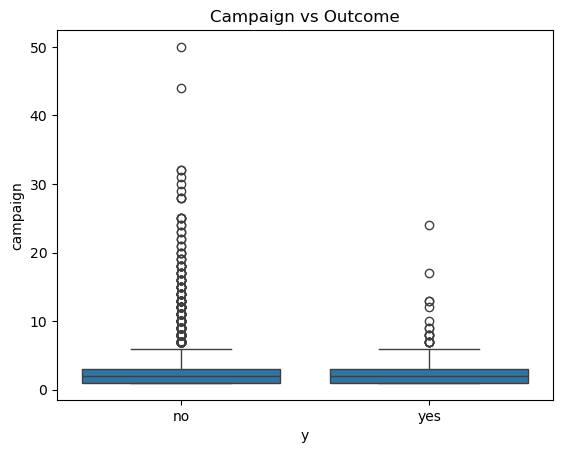

In [12]:
sns.boxplot(x='y', y='campaign', data=df)
plt.title("Campaign vs Outcome")
plt.show()

Customers who were contacted fewer times tend to subscribe more often.
Higher campaign values are generally associated with lower subscription rates.

7) Which month has the highest subscription rate?

In [13]:
subscription_rate = pd.crosstab(
    df['month'],
    df['y'],
    normalize='index'
)

subscription_rate = subscription_rate.sort_values(
    by='yes',
    ascending=False
)

print(subscription_rate)

y            no       yes
month                    
oct    0.537500  0.462500
dec    0.550000  0.450000
mar    0.571429  0.428571
sep    0.673077  0.326923
apr    0.808874  0.191126
feb    0.828829  0.171171
aug    0.875197  0.124803
jan    0.891892  0.108108
jun    0.896422  0.103578
nov    0.899743  0.100257
jul    0.913598  0.086402
may    0.933476  0.066524


October has the highest 'yes' rate, therefore, this month is the highest subscription rate.

 *) Average call duration by month

In [14]:
df.groupby('month')['duration'].mean()

month
apr    294.354949
aug    243.742496
dec    416.900000
feb    255.698198
jan    269.540541
jul    271.205382
jun    252.425612
mar    198.897959
may    267.316166
nov    272.066838
oct    272.800000
sep    215.730769
Name: duration, dtype: float64

In [15]:
avg_duration.plot(kind='bar')

NameError: name 'avg_duration' is not defined

9) How many records and how many attributes does the dataset contain ?

In [ ]:
print(df.shape) # rows, columns

(4521, 17)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


11) Check missing value

In [ ]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


Check 'unknown' values

In [ ]:
print(df.eq('unknown').sum())

age             0
job            38
marital         0
education     187
default         0
balance         0
housing         0
loan            0
contact      1324
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3705
y               0
dtype: int64


11) What is the targer variable?
y.

12) Are there any abnormal negative values (e.g., balance = -88) ? No.

In [ ]:
df[df['balance'] < 0]
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


13) Check and handle the value: pdays = -1. What does it mean ? Should it be replaced or converted to NaN ?

In [ ]:
import numpy as np
df['pdays'].value_counts()

pdays
182.0    23
183.0    20
92.0     12
363.0    12
91.0     11
         ..
118.0     1
386.0     1
63.0      1
81.0      1
234.0     1
Name: count, Length: 291, dtype: int64

In [ ]:
df['pdays'] = df['pdays'].replace(-1, np.nan)

pdays
182.0    23
183.0    20
92.0     12
363.0    12
91.0     11
         ..
118.0     1
386.0     1
63.0      1
81.0      1
234.0     1
Name: count, Length: 291, dtype: int64

14) Handle "unknown" values in columns such as: contact, poutcome

In [ ]:
df.replace('unknown', np.nan, inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

15) Check for duplicate records and remove them if any.

In [ ]:
df.duplicated().sum()
df.drop_duplicates()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,182.0,0,failure,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339.0,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330.0,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,cellular,3,jun,199,4,182.0,0,failure,no
4,59,blue-collar,married,secondary,no,0,yes,no,cellular,5,may,226,1,182.0,0,failure,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,182.0,0,failure,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,cellular,9,may,153,1,182.0,0,failure,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,182.0,0,failure,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211.0,3,other,no


16) Check and handle outliers in: balance, duration

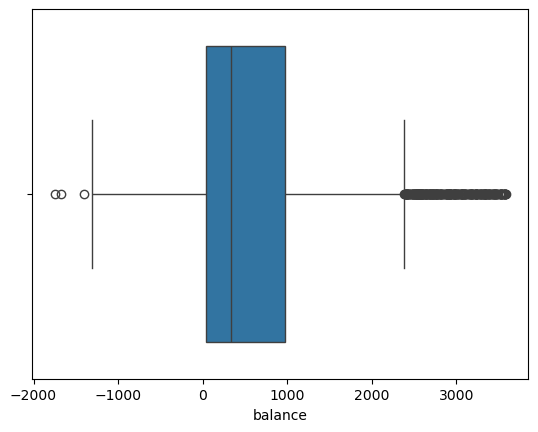

In [ ]:
sns.boxplot(x=df['balance'])
# IQR
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['balance'] >= lower) & (df['balance'] <= upper)]

17) Normalize numerical variables: age, balance, duration

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age','balance','duration']] = scaler.fit_transform(
    df[['age','balance','duration']]
)

18) Encode categorical variables

In [ ]:
df = pd.get_dummies(df, columns=[
    'job','marital','education','housing','loan'
])

Use One-hot Encoding because: suitable for ML and does not create fake ordinal numbers. Label encoding is prefer to un-ordinal variables.

19) Convert the variable month into numeric form (1 - 12).

In [ ]:
month_dict = {
'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}

df['month'] = df['month'].map(month_dict)

20) Create new variables: Age group (young, middle, senior), Total number of contacts (campaign + previous) and Binary variable: whether previously contacted or not.

In [ ]:
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,30,50,100],
    labels=['young','middle','senior']
)

In [ ]:
# Total contacts
df['total_contacts'] = df['campaign'] + df['previous']

In [ ]:
# Previously contacted?
import numpy as np
df['contacted_before'] = np.where(df['previous']>0, 1, 0)

21) Duration/Campaign

In [ ]:
df['duration_per_campaign'] = df['duration'] / df['campaign']

22) Yes/No rate

In [ ]:
print(df['y'].value_counts(normalize=True)*100,"%")

y
no     89.206519
yes    10.793481
Name: proportion, dtype: float64 %


Data imbalanced.

23) If the data is imbalanced, propose handling methods (undersampling, oversampling, SMOTE).


In [ ]:
# Oversampling
ros = RandomOverSampler()
# Undersampling
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE()

## Exercise 2:


Load data:

In [ ]:
df = pd.read_csv("Lab1_Ex2_titanic.csv")

print(df.head())
print(df.info())

   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St 

1) Survival rate = 38,1971%

In [ ]:
df['survived'].value_counts(normalize=True)

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

2) Gender distribution

In [ ]:
df['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

3) Ticket class distribution

In [ ]:
df['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

4) Age distribution

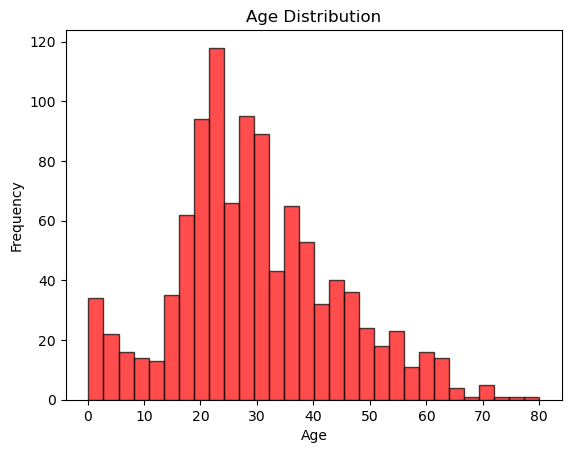

count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

In [ ]:
plt.hist(df['age'].dropna(),
         bins=30,
         color='red',
         edgecolor='black',
         alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

df['age'].describe()

5. Survival rate by gender

In [ ]:
pd.crosstab(df['sex'], df['survived'], normalize='index')

survived,0,1
sex,,
female,0.272532,0.727468
male,0.809015,0.190985


6. Survival rate by ticket class (pclass)


In [ ]:
pd.crosstab(df['pclass'], df['survived'], normalize='index')

survived,0,1
pclass,,
1,0.380805,0.619195
2,0.570397,0.429603
3,0.744711,0.255289


7. Survival rate by age group


In [ ]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,12,60,100],
    labels=['child','adult','senior']
)

pd.crosstab(df['age_group'], df['survived'], normalize='index')

survived,0,1
age_group,,
child,0.425532,0.574468
adult,0.602829,0.397171
senior,0.757576,0.242424


8) Compare fare (boxplot)

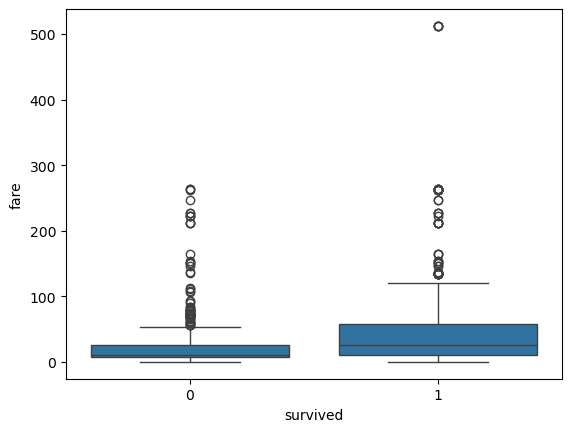

In [ ]:
sns.boxplot(x='survived', y='fare', data=df)
plt.show()

The survived group pays more.

9. How many rows and columns does the dataset have ?

In [ ]:
df.shape

(1309, 15)

10.What is the meaning of each variable (pclass, sibsp, parch, boat, body, etc.)?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   int64   
 2   name       1309 non-null   object  
 3   sex        1309 non-null   object  
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   object  
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
 14  age_group  1046 non-null   category
dtypes: category(1), float64(3), int64(4), object(7)
memory usage: 144.7+ KB


11.Is the survival variable (survived) imbalanced ?

In [ ]:
df['survived'].value_counts(normalize=True)

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

12.Check columns with missing values: age, cabin, embarked, boat, body, home.dest

In [ ]:
df['survived'].value_counts(normalize=True)

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

12) Missing values

In [ ]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
age_group     263
dtype: int64

13.Should we remove columns such as: name, ticket, boat, body ? Why ?

We should remove these columns because they do not have clearly prediction meaning, moreover, boat and body lead to data leakage.

In [ ]:
df.drop(columns=['name','ticket','boat','body'], inplace=True)

14.Handle missing values in: age (fill with mean/median or by group: sex + pclass ?) embarked (fill with mode ?)


In [ ]:
df['age'] = df.groupby(['sex','pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_8300\1964997694.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


15.Check and handle duplicate records

In [ ]:
df.groupby(['sex','pclass'])['age'].transform('median')

0       36.0
1       42.0
2       36.0
3       42.0
4       36.0
        ... 
1303    25.0
1304    22.0
1306    25.0
1307    25.0
1308    25.0
Name: age, Length: 1176, dtype: float64

In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

16) Encode categorical

In [ ]:
df = pd.get_dummies(df, columns=['sex','embarked','pclass'])

17.Should we normalize variables such as age and fare? When is normalization necessary?

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age','fare']] = scaler.fit_transform(df[['age','fare']])

NameError: name 'df' is not defined

18) Extract title from name

In [ ]:
df['title'] = df['name'].str.extract(' ([A-Za-z]+)\.')
df['title'].value_counts()

19) Family_size & is_alone

In [ ]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = np.where(df['family_size']==1, 1, 0)

20) Age group

In [ ]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,12,60,100],
    labels=['child','adult','senior']
)

21) cabin_know

In [ ]:
df['cabin_known'] = np.where(df['cabin'].notnull(),1,0)

22) Fare_per_person

In [ ]:
df['fare_per_person'] = df['fare'] / df['family_size']

23. Outliers fare, age

In [ ]:
sns.boxplot(x=df['fare'])
plt.show()
# IQR
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['fare'] >= Q1 - 1.5 * IQR) & (df['fare'] <= Q3 + 1.5 * IQR)]
sns.boxplot(x=df_filtered['fare'])
plt.show()

24. Should we handle fare = 0? 

In [ ]:
df[df['fare']==0]

## Exercise 3: BDS_TPHCM

0) Load data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Lab1_Ex3_BDS_TPHCM.csv")

print(df.head())
print(df.info())

   Phòng ăn         Pháp lý addressLocality  Số phòng ngủ     price_text  \
0       NaN  Sổ hồng/ Sổ đỏ      Xã Cần Giờ           NaN         3,3 tỷ   
1       NaN  Giấy tờ hợp lệ      Xã Cần Giờ           3.0          20 tỷ   
2       NaN  Sổ hồng/ Sổ đỏ      Xã Cần Giờ           1.0  16 triệu / m²   
3       NaN  Sổ hồng/ Sổ đỏ      Xã Cần Giờ           1.0  16 triệu / m²   
4       NaN  Sổ hồng/ Sổ đỏ      Xã Cần Giờ           1.0  16 triệu / m²   

   Chính chủ addressRegion Đường trước nhà  \
0        NaN   Hồ Chí Minh              8m   
1        NaN   Hồ Chí Minh             14m   
2        NaN   Hồ Chí Minh             20m   
3        NaN   Hồ Chí Minh             20m   
4        NaN   Hồ Chí Minh             16m   

                                         description Chiều dài  ...  \
0  Diện tích 4.5 x 22 m\r\n      Cần bán gấp kinh...       22m  ...   
1  PHÂN KHU B – VINHOMES GREEN PARADISE CẦN GIỜ 🌴...       15m  ...   
2  🏞️ TIN 4: BÁN ĐẤT VIEW ĐẸP SÁT VINHOMES CẦN GI... 

REQUIREMENT 1:
Restructure addressLocality

In [33]:
ward_map = {
"Tân Định":"Tan Dinh Ward",
"Sài Gòn":"Sai Gon Ward",
"Bến Thành":"Ben Thanh Ward",
"Cầu Ông Lãnh":"Cau Ong Lanh Ward"
}

def convert_ward(address):
    for old,new in ward_map.items():
        if old in str(address):
            return new
    return address

df['new_ward'] = df['addressLocality'].apply(convert_ward)

df[['addressLocality','new_ward']].head()

,addressLocality,new_ward
0,Xã Cần Giờ,Xã Cần Giờ
1,Xã Cần Giờ,Xã Cần Giờ
2,Xã Cần Giờ,Xã Cần Giờ
3,Xã Cần Giờ,Xã Cần Giờ
4,Xã Cần Giờ,Xã Cần Giờ


REQUIREMENT 2:
Clean columns

In [34]:
df['price_value'] = (
df['price_value']
.astype(str)
.str.replace('tỷ','')
.str.replace(',','')
)

df['price_value'] = pd.to_numeric(df['price_value'], errors='coerce')

df['area'] = pd.to_numeric(df['area'], errors='coerce')

Text values in price_value and area were converted to numeric format to allow quantitative analysis.

3) Histogram of price

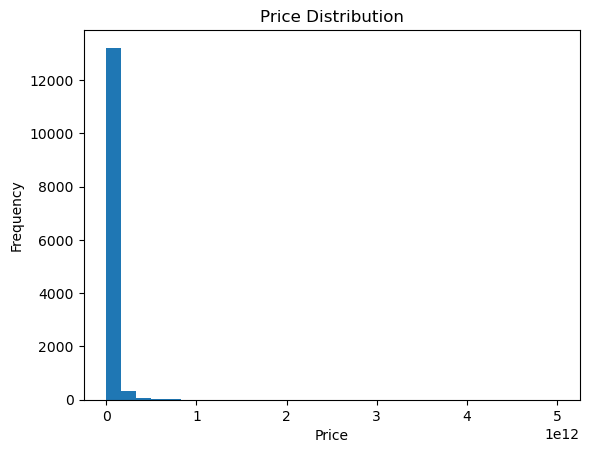

In [35]:
plt.hist(df['price_value'].dropna(), bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most properties are concentrated in the lower price ranges, with a small number of very high-priced listings.

4. Histogram of area

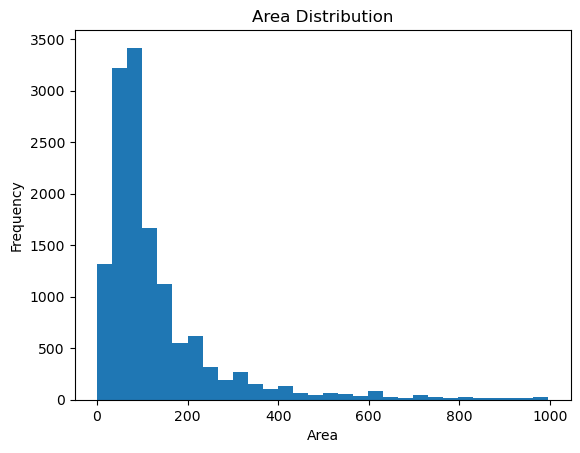

In [36]:
plt.hist(df['area'].dropna(), bins=30)
plt.title("Area Distribution")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

Most properties have an area between 40 m² and 120 m², while very large properties appear as outliers.

5. Compare price by ward

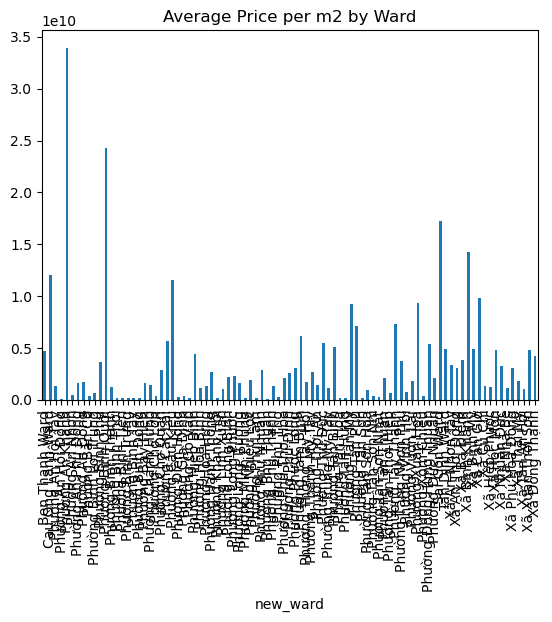

In [37]:
df['price_per_m2'] = df['price_value'] / df['area']

df.groupby('new_ward')['price_per_m2'].mean().plot(kind='bar')
plt.title("Average Price per m2 by Ward")
plt.show()

Average price per square meter varies across wards. Central wards usually have higher prices.

6. Price per m2 by property type

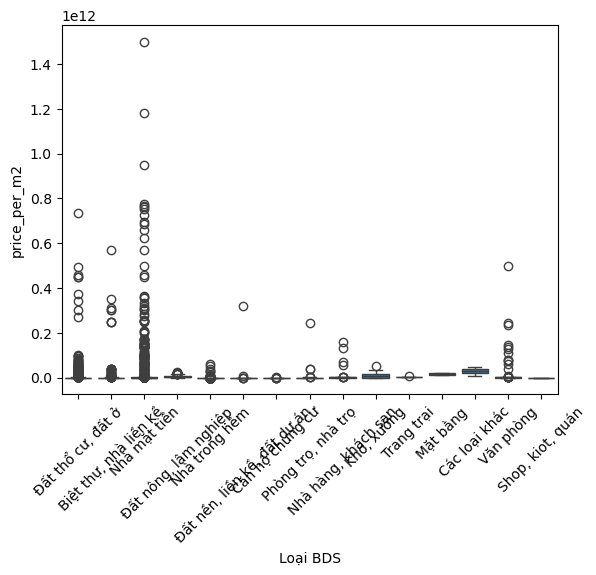

In [38]:
sns.boxplot(x='Loại BDS', y='price_per_m2', data=df)
plt.xticks(rotation=45)
plt.show()

Different property types show different price distributions. Villas and townhouses generally have higher prices per square meter.

7. Scatter plot area vs price

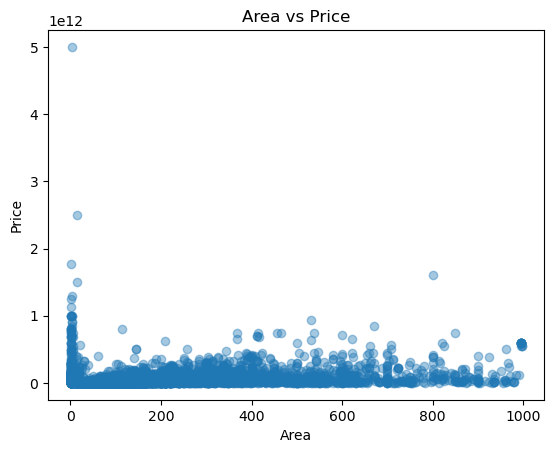

In [39]:
plt.scatter(df['area'], df['price_value'], alpha=0.4)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")

plt.show()

The scatter plot indicates a positive relationship between property area and price, although there is considerable variability.

8. Boxplot price by property type

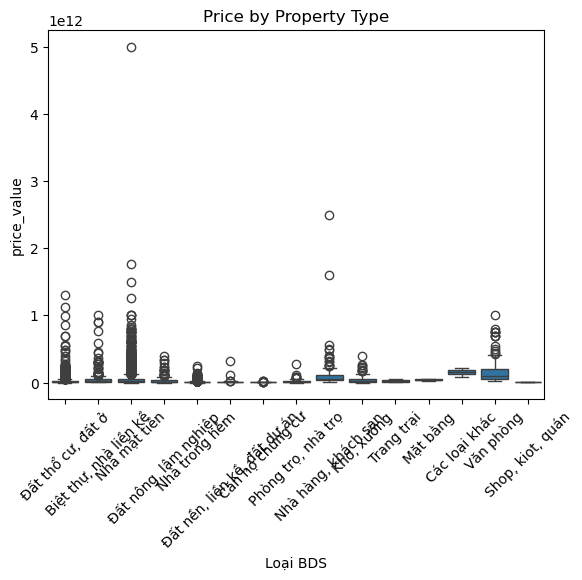

In [40]:
sns.boxplot(x='Loại BDS', y='price_value', data=df)

plt.xticks(rotation=45)
plt.title("Price by Property Type")

plt.show()

The boxplot reveals that certain property types have significantly higher median prices and larger price variability.

9. Rows and columns

In [41]:
df.shape

(13700, 27)

The dataset contains N rows and M columns (replace with actual numbers from your output).

11. Categorical columns

In [42]:
df.select_dtypes(include='object').columns

Index(['Pháp lý', 'addressLocality', 'price_text', 'addressRegion',
       'Đường trước nhà', 'description', 'Chiều dài', 'streetAddress',
       'Thuộc dự án', 'Hướng', 'title', 'Loại BDS', 'Chiều ngang', 'Loại tin',
       'Số lầu', 'address_old', 'new_ward'],
      dtype='object')

Categorical columns include property type, address information, and location attributes.

12. Number of listings by property type

In [43]:
df['Loại BDS'].value_counts()

Loại BDS
Nhà trong hẻm                  5744
Nhà mặt tiền                   5143
Đất thổ cư, đất ở              1501
Biệt thự, nhà liền kề           515
Văn phòng                       158
Kho, xưởng                      131
Đất nông, lâm nghiệp            123
Nhà hàng, khách sạn             115
Phòng trọ, nhà trọ              104
Đất nền, liền kề, đất dự án      81
Căn hộ chung cư                  74
Trang trại                        6
Mặt bằng                          2
Các loại khác                     2
Shop, kiot, quán                  1
Name: count, dtype: int64

The distribution shows which property types appear most frequently in the dataset.

13. Average price

In [44]:
df['price_value'].mean()

np.float64(35145452590.21898)

14. Missing values

In [45]:
df.isnull().sum()

Phòng ăn           13700
Pháp lý             3680
addressLocality        0
Số phòng ngủ        1730
price_text             0
Chính chủ          13700
addressRegion          0
Đường trước nhà       41
description            0
Chiều dài           2010
streetAddress          0
Sân thượng         13700
Thuộc dự án        13529
Hướng              12450
title                  0
Loại BDS               0
Nhà bếp            13700
Chiều ngang         1803
price_value            0
area                   0
Loại tin               0
Mã tin                 0
Chổ để xe hơi      13700
Số lầu              2084
address_old            0
new_ward               0
price_per_m2           0
dtype: int64

Some columns contain missing values and may require cleaning or imputation.

15. Duplicate records

In [46]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

Duplicate listings were checked and removed to ensure data quality.

17. Standardize units

In [47]:
df['Chiều dài'] = pd.to_numeric(df['Chiều dài'], errors='coerce')
df['Chiều ngang'] = pd.to_numeric(df['Chiều ngang'], errors='coerce')